# 4. Model Training with Second-Order Optimizers

We can use second-order optimizers to improve the training precision and potentially get better fit results. 

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import torch
from m3util.viz.printing import printer
from m3util.viz.style import set_style
from m3util.ml.rand import set_seeds
from m3util.ml.optimizers.AdaHessian import AdaHessian
from m3util.ml.optimizers.TrustRegion import TRCG
from m3util.util.IO import download_and_unzip, make_folder
from belearn.dataset.dataset import BE_Dataset
from belearn.viz.viz import Viz
from belearn.functions.sho import SHO_nn
from autophyslearn.postprocessing.complex import ComplexPostProcessor
from autophyslearn.spectroscopic.nn import Multiscale1DFitter, Model


printing = printer(basepath = './Figures/')

set_style("printing")
set_seeds(seed=42)

%matplotlib inline

printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42


2025-04-18 12:03:02.949091: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744992182.964730 1861778 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744992182.969583 1861778 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-18 12:03:02.985666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow seed was set to 42


## Loads Data


In [2]:
# Specify the filename and the path to save the file
filename = "./data_raw.h5"
save_path = "./Data"


data_path = save_path + "/" + filename

# instantiate the dataset object
# JGoddy commented out the SHO_fit_func_LSQF because I don't think it is actually used anywhere in the code
#dataset = BE_Dataset(data_path, SHO_fit_func_LSQF=SHO_nn)

dataset = BE_Dataset(data_path)


# print the contents of the file
dataset.print_be_tree

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

In [3]:
# instantiates the visualization object
BE_viz = Viz(dataset, printing, verbose=True)

In [4]:
BE_viz.SHO_preprocessing()

In [5]:
BE_viz.SHO_Scaler()

## ADAM model

In [6]:
# constructs a test train split
X_train, X_test, y_train, y_test = BE_viz.test_train_split_(shuffle=True)

set_seeds(seed=42)
device = torch.device("cuda:0")

postprocessor = ComplexPostProcessor(BE_viz, device=device)

ADAM_model_ = Multiscale1DFitter(SHO_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor)

# instantiate the model
ADAM_model = Model(ADAM_model_, BE_viz, 
                   training=True, model_basename="SHO_Fitter_original_data", 
                   datafed_path = "2024_SHO_Fitting/Adam_NN_SHO_Fitter", 
                   script_path = f"{os.getcwd()}/4_Second_Order_Optimizers copy.ipynb")

ADAM_model.fit(
    X_train,
    5000,
    optimizer="Adam",
    epochs = 5,
)




            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            
data type <class 'numpy.ndarray'>

            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resam

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/torch/csrc/autograd/engine.cpp:1201.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam
epoch : 1/5, recon loss = 0.32030000
--- 9.479018449783325 seconds ---
Epoch 1, Learning Rate: 0.001
Adam
epoch : 2/5, recon loss = 0.04120343
--- 9.119497776031494 seconds ---
Epoch 2, Learning Rate: 0.001
Adam
epoch : 3/5, recon loss = 0.03719935
--- 9.07990550994873 seconds ---
Epoch 3, Learning Rate: 0.001
Adam
epoch : 4/5, recon loss = 0.03625259
--- 9.120753765106201 seconds ---
Epoch 4, Learning Rate: 0.001
Adam
epoch : 5/5, recon loss = 0.03580352
--- 9.090429782867432 seconds ---
Epoch 5, Learning Rate: 0.001


## Adahessian

We first try an optimized called [adahessian](https://arxiv.org/abs/2006.00719)

In [7]:
# constructs a test train split
X_train, X_test, y_train, y_test = BE_viz.test_train_split_(shuffle=True)

set_seeds(seed=42)

postprocessor = ComplexPostProcessor(BE_viz,device=device)

AdaHessian_ = Multiscale1DFitter(SHO_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor)

# instantiate the model
AdaHessian_model = Model(AdaHessian_, BE_viz, training=True, 
                         model_basename="SHO_Fitter_original_data_adahessian",
                        datafed_path = "2024_SHO_Fitting/AdaHessian_NN_SHO_Fitter", 
                       script_path = f"{os.getcwd()}/4_Second_Order_Optimizers.ipynb")


AdaHessian_model.fit(
    X_train,
    5000,
    optimizer="AdaHessian",
    epochs = 5,
     lr=0.15
)



            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            
data type <class 'numpy.ndarray'>

            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resam

### Evaluate the Neural Network Results

It is always recommended to validate that the autoencoder is working correctly. We can do this by comparing the different stages of the autoencoder including the raw data, the generated curves.


index1 [176671 364646 443409]
./Figures/Figure_4_1_NN_Adahessian_SHO_Fits_training_test.png
./Figures/Figure_4_1_NN_Adahessian_SHO_Fits_training_test.svg


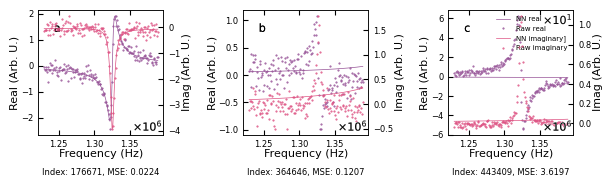

In [8]:
d1, d2, index1, mse1 = BE_viz.bmw_nn(
    X_train,
    prediction=AdaHessian_model,
    out_state={"scaled": True, "raw_format": "complex"},
    returns=True,
    filename="Figure_4_1_NN_Adahessian_SHO_Fits_training_test",
)

**Figure 4.1** Raw data and reconstruction of the autoencoder trained with Adahessian for the training data. Shows the a) best, b) median, and c) worst reconstruction of the training data.

index1 [ 75573 158953   5821]
./Figures/Figure_4_2_NN_Adahessian_SHO_Fits_testing_test.png
./Figures/Figure_4_2_NN_Adahessian_SHO_Fits_testing_test.svg


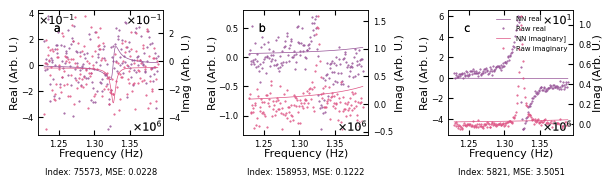

In [9]:
d1, d2, index1, mse1 = BE_viz.bmw_nn(
    X_test,
    prediction=AdaHessian_model,
    out_state={"scaled": True, "raw_format": "complex"},
    returns=True,
    filename="Figure_4_2_NN_Adahessian_SHO_Fits_testing_test",
)

**Figure 4.2** Raw data and reconstruction of the autoencoder trained with Adahessian for the testing data. Shows the a) best, b) median, and c) worst reconstruction of the testing data.


            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            
data type <class 'numpy.ndarray'>
index1 [1327367 1132546  133213]
./Figures/Figure_4_3_NN_Adahessian_SHO_Fits_testing_test.png
./Fi

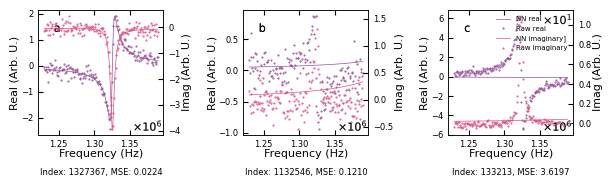

In [10]:
state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
}

X_data, Y_data = BE_viz.NN_data()

d1, d2, index1, mse1 = BE_viz.bmw_nn(
    state,
    prediction=AdaHessian_model,
    out_state={"scaled": True, "measurement State": "complex"},
    returns=True,
    filename="Figure_4_3_NN_Adahessian_SHO_Fits_testing_test",
)

**Figure 4.3** Raw data and reconstruction of the autoencoder trained with Adahessian for the entire data. Shows the a) best, b) median, and c) worst reconstruction of the entire data.

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)



            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            
./Figures/Figure_13_NN_Unscaled_Parameters_Histograms_test.png
./Figures/Figure_13_NN_Unscaled_Parameters_Histograms_t

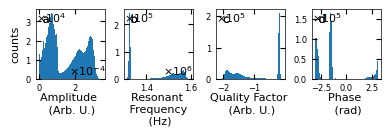

In [11]:
# we will add the appropriate phase shift to the dataset based on the fix seed,
# If your seed is different the results might vary
BE_viz.NN_phase_shift = np.pi/2 

# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = AdaHessian_model.predict(X_data)

BE_viz.SHO_hist(parm, filename="Figure_13_NN_Unscaled_Parameters_Histograms_test")

**Figure 4.4** Histogram of the fit results computed with the Adahessian optimized neural network for the a) amplitude, b) resonance frequency, c) quality factor, and d) phase.

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
./Figures/Figure_3_5_NN_Switching_Maps.png
./Figures/Figure_3_5_NN_Switching_Maps.svg


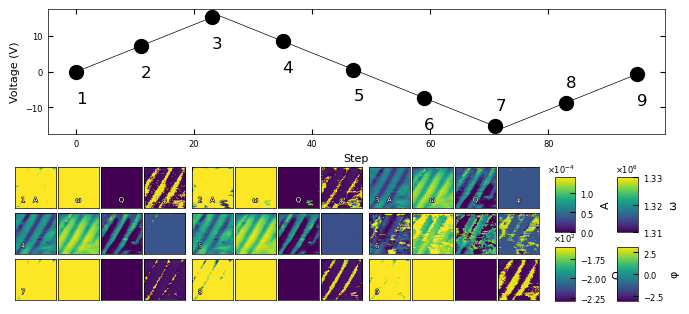

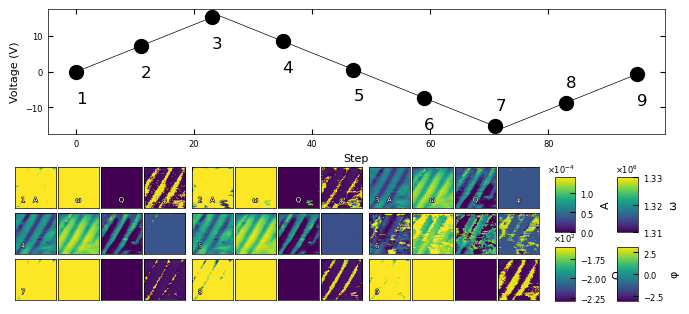

In [12]:
# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = AdaHessian_model.predict(X_data)

BE_viz.SHO_switching_maps(parm, filename="Figure_3_5_NN_Switching_Maps_test")

**Figure 4.5** Snapshots of the amplitude, resonance frequency, quality factor, and phase of the piezoresponse during ferroelectric switching based on adahessian optimizer fits.


            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=

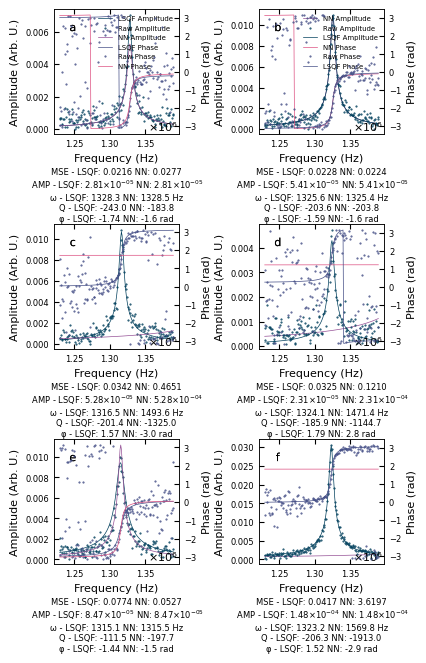

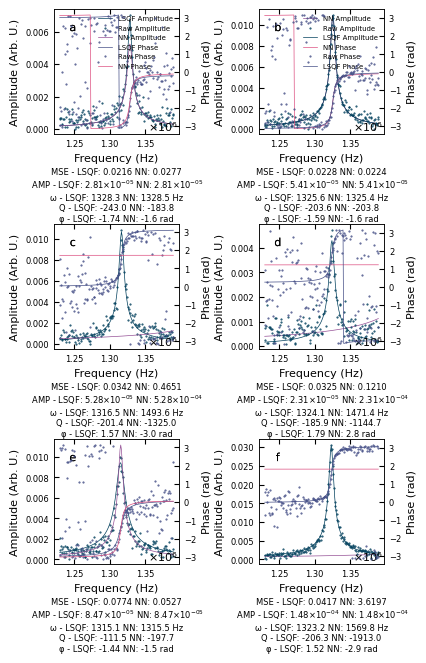

In [14]:
BE_viz.NN_phase_shift = np.pi/2
BE_viz.LSQF_phase_shift = np.pi/2
BE_viz.measurement_state = "all"


true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

n = 1

LSQF = BE_viz.get_best_median_worst(
    true_state,
    prediction={"fitter": "LSQF"},
    out_state=out_state,
    SHO_results=True,
    n=n,
)

NN = BE_viz.get_best_median_worst(
    true_state, prediction=AdaHessian_model, out_state=out_state, SHO_results=True, n=n
)

data = (LSQF, NN)
names = ["LSQF", "NN"]

BE_viz.SHO_Fit_comparison(
    data,
    names,
    model_comparison=[AdaHessian_model, {"fitter": "LSQF"}],
    out_state=out_state,
    filename="Figure_4_5_LSQF_NN_bmw_comparison_test",
)

**Figure 4.6** Comparison of the a,b) best, c,d) median, and e,f) worst simple harmonic oscillator fits. a,c,e) are based on the fit results from the simple harmonic oscillator model, wherein b,d,f) are based on the neural network model trained with the Adahessian optimizer. Generally speaking, all fits are good for both models on the as collected data.

./Figures/Figure_4_7_Violin_plot_comparison_SHO_AdaHessian_test.png
./Figures/Figure_4_7_Violin_plot_comparison_SHO_AdaHessian_test.svg


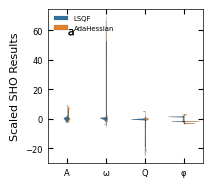

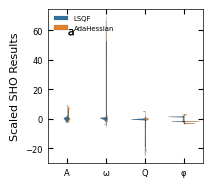

In [16]:
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

BE_viz.violin_plot_comparison_SHO(true_state, AdaHessian_model, X_data, label='AdaHessian',
                                  filename="Figure_4_7_Violin_plot_comparison_SHO_AdaHessian_test") 

**Figure 4.7** Comparison of the least-squares and adahessian optimized neural network fitting results.

## Trust Region Optimizer

In [17]:
optimizer = {"name": "TRCG", "optimizer":TRCG, "radius": 5, "device": "cuda","ADAM_epochs": 2}

# constructs a test train split
X_train, X_test, y_train, y_test = BE_viz.test_train_split_(shuffle=True)

set_seeds(seed=42)

postprocessor = ComplexPostProcessor(BE_viz,device=device)

TRCG_ = Multiscale1DFitter(SHO_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor)

# instantiate the model
TRCG_model = Model(TRCG_, BE_viz, training=True, model_basename="SHO_Fitter_original_data_TRCG",
                   datafed_path = "2024_SHO_Fitting/TR_NN_SHO_Fitter", 
                   script_path = f"{os.getcwd()}/4_Second_Order_Optimizers.ipynb")

TRCG_model.fit(
    X_train,
    5000,
    optimizer=optimizer,
    epochs = 5,
)


            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=

In [19]:
optimizer = {"name": "TRCG", "optimizer":TRCG, "radius": 5, "device": "cuda","ADAM_epochs": 2}

# constructs a test train split
X_train, X_test, y_train, y_test = BE_viz.test_train_split_(shuffle=True)

set_seeds(seed=42)

postprocessor = ComplexPostProcessor(BE_viz,device=device)

TRCG_ = Multiscale1DFitter(SHO_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor)

# instantiate the model
TRCG_model = Model(TRCG_, BE_viz, training=True, model_basename="SHO_Fitter_original_data_TRCG",
                   datafed_path = "2024_SHO_Fitting/TR_NN_SHO_Fitter", 
                   script_path = f"{os.getcwd()}/4_Second_Order_Optimizers.ipynb")




TRCG_model.fit(
    X_train,
    5000,
    optimizer=optimizer,
    epochs = 5,
)


            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=

### Evaluate the Neural Network Results

It is always recommended to validate that the autoencoder is working correctly. We can do this by comparing the different stages of the autoencoder including the raw data, the generated curves.


index1 [127153 110176 909571]
./Figures/Figure_4_8_NN_TrustRegion_SHO_Fits_training_test.png
./Figures/Figure_4_8_NN_TrustRegion_SHO_Fits_training_test.svg


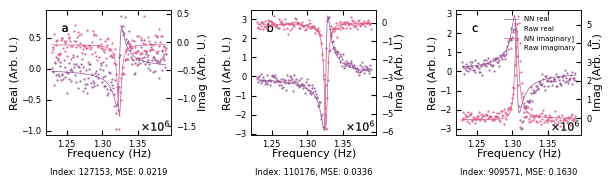

In [20]:
d1, d2, index1, mse1 = BE_viz.bmw_nn(
    X_train,
    prediction=TRCG_model,
    out_state={"scaled": True, "raw_format": "complex"},
    returns=True,
    filename="Figure_4_8_NN_TrustRegion_SHO_Fits_training_test",
)

**Figure 4.8** Raw data and reconstruction of the autoencoder trained with Trust Region for the training data. Shows the a) best, b) median, and c) worst reconstruction of the training data.

index1 [ 75573 132150  85895]
./Figures/Figure_4_9_NN_TrustRegion_SHO_Fits_testing_test.png
./Figures/Figure_4_9_NN_TrustRegion_SHO_Fits_testing_test.svg


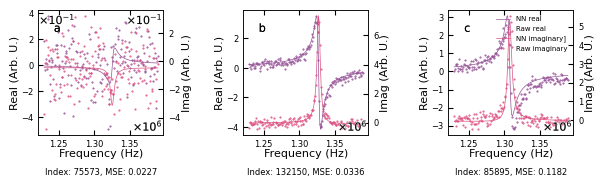

In [21]:
d1, d2, index1, mse1 = BE_viz.bmw_nn(
    X_test,
    prediction=TRCG_model,
    out_state={"scaled": True, "raw_format": "complex"},
    returns=True,
    filename="Figure_4_9_NN_TrustRegion_SHO_Fits_testing_test",
)

**Figure 4.9** Raw data and reconstruction of the autoencoder trained with trust region for the testing data. Shows the a) best, b) median, and c) worst reconstruction of the testing data.


            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            
index1 [1291703  351730   21130]
./Figures/Figure_4_10_NN_validation_full_data_test.png
./Figures/Figure_4_1

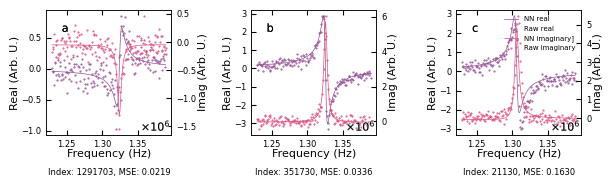

In [22]:
state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
}

X_data, Y_data = BE_viz.NN_data()

d1, d2, index1, mse1 = BE_viz.bmw_nn(
    state,
    prediction=TRCG_model,
    out_state={"scaled": True, "measurement State": "complex"},
    returns=True,
    filename="Figure_4_10_NN_validation_full_data_test",
)

**Figure 4.10** Raw data and reconstruction of the autoencoder trained with Adahessian for the entire data. Shows the a) best, b) median, and c) worst reconstruction of the entire data.

dataset is scaled


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)



            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            
./Figures/Figure_4_11_NN_Unscaled_Parameters_Histograms_test.png
./Figures/Figure_4_11_NN_Unscaled_Parameter

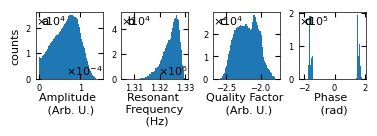

In [23]:
# we will add the appropriate phase shift to the dataset based on the fix seed,
# If your seed is different the results might vary
BE_viz.NN_phase_shift = np.pi/2 

# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = TRCG_model.predict(X_data)

BE_viz.SHO_hist(parm, filename="Figure_4_11_NN_Unscaled_Parameters_Histograms_test")

**Figure 4.11** Histogram of the fit results computed with the trust region optimized neural network for the a) amplitude, b) resonance frequency, c) quality factor, and d) phase.

In [28]:
BE_viz.scaled = False
BE_viz.set_preprocessing()
BE_viz.scaled = True

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


In [33]:
BE_viz.measurement_state

'all'

./Figures/Figure_4_12_NN_Switching_Maps_test2.png
./Figures/Figure_4_12_NN_Switching_Maps_test2.svg


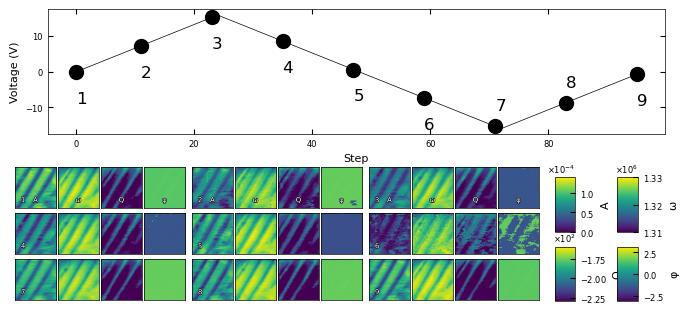

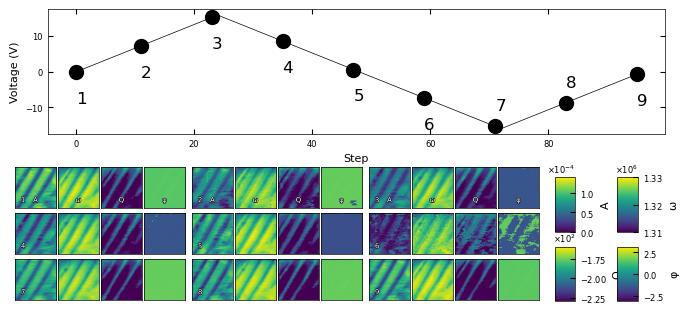

In [36]:
# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = TRCG_model.predict(X_data)

BE_viz.SHO_switching_maps(parm, filename="Figure_4_12_NN_Switching_Maps_test2")

**Figure 4.12** Snapshots of the amplitude, resonance frequency, quality factor, and phase of the piezoresponse during ferroelectric switching based on the trust region optimizer fits.


            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = None
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/./data_raw.h5', noise=0, resampled_bins=None, resampled_da

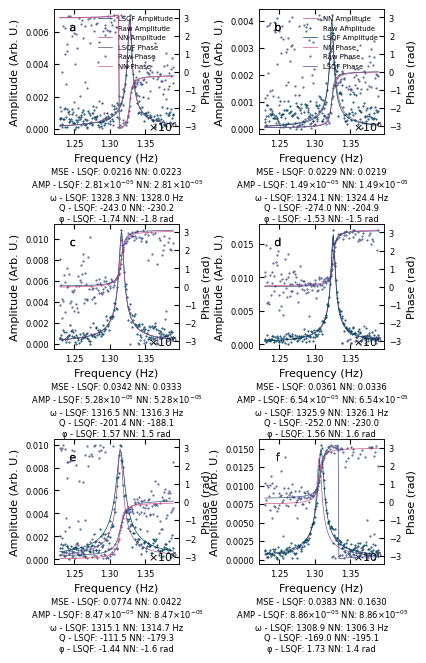

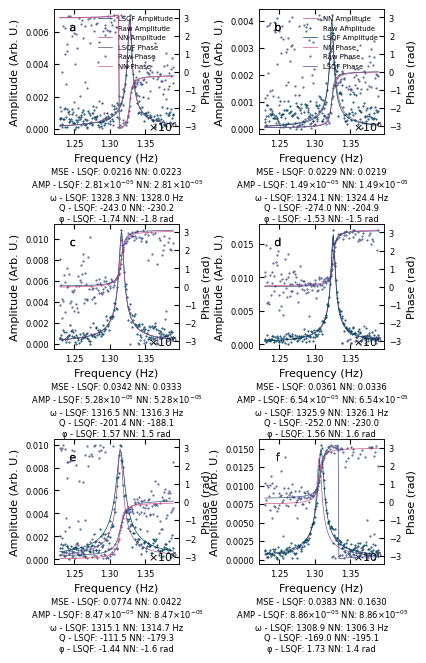

In [37]:
BE_viz.NN_phase_shift = np.pi/2
BE_viz.LSQF_phase_shift = np.pi/2
BE_viz.measurement_state = "all"


true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

n = 1

LSQF = BE_viz.get_best_median_worst(
    true_state,
    prediction={"fitter": "LSQF"},
    out_state=out_state,
    SHO_results=True,
    n=n,
)

NN = BE_viz.get_best_median_worst(
    true_state, prediction=TRCG_model, out_state=out_state, SHO_results=True, n=n
)

data = (LSQF, NN)
names = ["LSQF", "NN"]

BE_viz.SHO_Fit_comparison(
    data,
    names,
    model_comparison=[TRCG_model, {"fitter": "LSQF"}],
    out_state=out_state,
    filename="Figure_4_13_LSQF_NN_bmw_comparison_Trust_Region_test",
    # display_results = None
)

**Figure 4.13:** Comparison of the a, b) best, c, d) median, and e, f) worst simple harmonic oscillator fits. a, c, e) are based on the fit results from the simple harmonic oscillator model, whereas b, d, f) are based on the neural network model trained with the Trust Region Optimizer. Generally speaking, all fits are good for both models on the collected data. The Trust Region Optimizer has lower maximum errors than the other neural network models.

./Figures/Figure_4_14_Violin_Trust_Region_test.png
./Figures/Figure_4_14_Violin_Trust_Region_test.svg


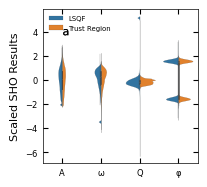

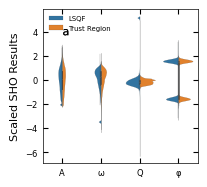

In [38]:
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}


BE_viz.violin_plot_comparison_SHO(true_state, TRCG_model, X_data, filename="Figure_4_14_Violin_Trust_Region_test", label="Trust Region") 

**Figure 4.14** Comparison of the least-squares and trust region-optimized neural network fitting results.